Objective To build a Convoultinal Autoencoder that compress facial images into lower-dimensional latent representation and recounstrus them with minimal loss of information

Purpose A Convolutinoal Autoencoder is an unsupervised deep learning model used for: Iamge Compression Image recostruction Feature Extraction Dimenstinality Reduction The encoder learns a compressed represetntation,While the decoder reconstructs the original image from this compressed representation

In [1]:
import os
import shutil #moving and coping files
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


In [2]:
import kagglehub

path=kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Dataset download txt",path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset download txt /kaggle/input/celeba-dataset


In [3]:
import os
import shutil #moving and coping files

#create a smaller Dataset (500 Images)
source_folder =os.path.join(path,"img_align_celeba","img_align_celeba")

destination_folder="celeda_small/faces"

os.makedirs(destination_folder,exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder,img),
        os.path.join(destination_folder,img),
    )
print("Copied",len(images),"images")

Copied 5000 images


In [6]:
#Data preprocessing
IMAGE_SIZE=(128,128)

BATCH_SIZE=64

In [7]:
datagen =ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2

)

In [8]:
#Load Dataset
train_generator =datagen.flow_from_directory(
    "celeda_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [9]:
validation_generator =datagen.flow_from_directory(
    "celeda_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


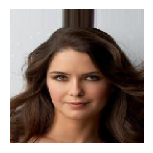

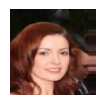

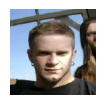

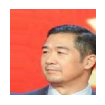

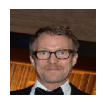

In [10]:
#Display Sample Images
images, _ =next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.show()

In [11]:
#Build Convolutional Autoencoder
#encoder
input_img =Input(shape=(128,128,3))
x=Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(input_img)

x=MaxPooling2D(
    (2,2),
    padding="same"
    )(x)

x=Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)

encoded=MaxPooling2D(
 (2,2),
 padding="same"
)(x)



In [12]:
#Decoder
x=Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(encoded)

x=UpSampling2D((2,2))(x)
x=Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
)(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(
    3,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

In [13]:
# Create Model
#create model
autoencoder=Model(
    input_img,
    decoded
)

In [15]:

#compie model
autoencoder.compile(optimizer="adam",loss="binary_crossentropy")

In [16]:
#model Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,979 (371.01 KB)

 Trainable params: 94,979 (371.01 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#train model
history=autoencoder.fit(
    train_generator,

    validation_data=validation_generator,
    epochs=50
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 277ms/step - loss: 0.5374 - val_loss: 0.4911
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.4871 - val_loss: 0.4846
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.4836 - val_loss: 0.4825
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.4807 - val_loss: 0.4802
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.4798 - val_loss: 0.4800
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.4790 - val_loss: 0.4787
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.4781 - val_loss: 0.4782
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.4774 - val_loss: 0.4785
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.4772 - val_loss: 0.4769
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - loss: 0.4772 - val_loss: 0.4786
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.4765 - val_loss: 0.4767
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - l

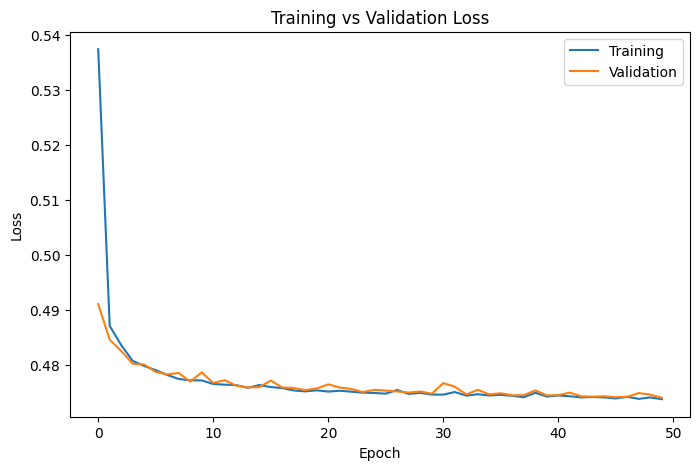

In [18]:
#plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.title("Training vs Validation Loss")
plt.legend(["Training","Validation"])
plt.show()

In [19]:
#evaluate MODEL
loss=autoencoder.evaluate(validation_generator)
print("Validation Loss:",loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.4740
Validation Loss: 0.4739987254142761


In [20]:
#Reconstruct Images
images,_=next(validation_generator)
reconstructed=autoencoder.predict(images)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


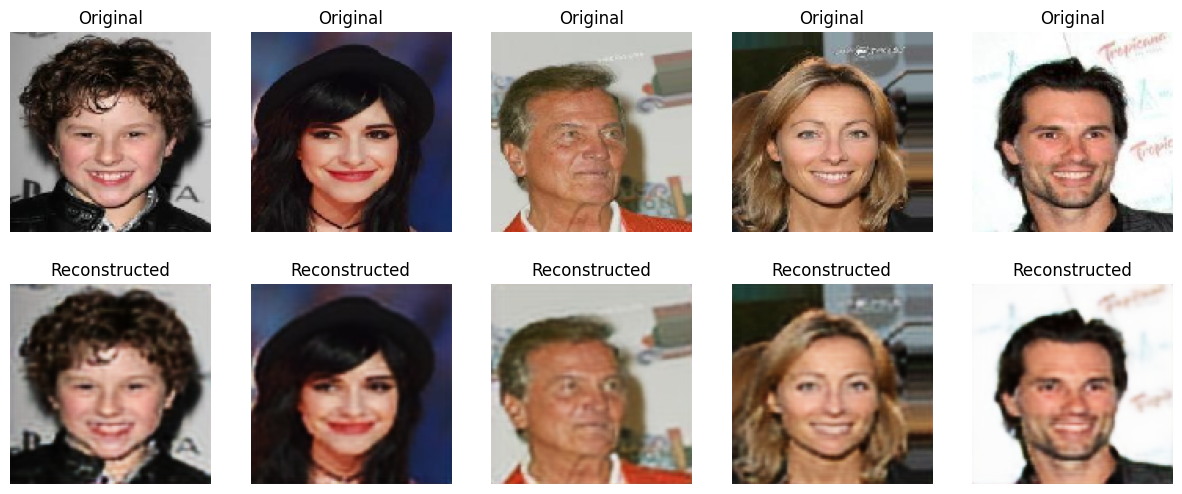

In [21]:
#Display Results
n=5
plt.figure(figsize=(15,6))
for i in range(n):

    plt.subplot(2,n,i+1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")
    plt.subplot(2,n,i+1+n)
    plt.imshow(reconstructed[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()